# Sección 4 (parte B): Word2Vec de gensim y GloVe preentrenado

In [1]:
import os, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim.downloader as api
from gensim.models import Word2Vec, KeyedVectors

import utils as U
import evaluation as EV
import corpus_cache as CC

SEED = 42
CACHE = Path("cache")
RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)
pd.options.display.float_format = "{:.4f}".format

/Users/marinesgarcia/Documents/UVG/DL/venv-lab7/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 4.B.1 Mismo corpus y mismo vocabulario que el SGNS propio

In [2]:
itos, counts, ids, offsets, meta = CC.load_corpus_cache(CACHE)

words = np.array(itos, dtype=object)
sentences = [words[ids[offsets[p]:offsets[p + 1]]].tolist() for p in range(len(offsets) - 1)]
freq = {w: int(c) for w, c in zip(itos[2:], counts[2:])}      # sin <pad> ni <unk>

print(f"Párrafos (oraciones): {len(sentences):,} | tokens: {len(ids):,}")
print(f"Vocabulario sin <pad>/<unk>: {len(freq):,} palabras | min_count del preprocesamiento: {meta['min_count']}")

Corpus: 29,552,958 tokens en 303,140 párrafos | vocabulario: 109,646 (incluye <pad>, <unk>)


Párrafos (oraciones): 303,140 | tokens: 29,552,958
Vocabulario sin <pad>/<unk>: 109,644 palabras | min_count del preprocesamiento: 5


## 4.B.2 Word2Vec de gensim (skip-gram + negative sampling)

In [3]:
GENSIM_CFG = dict(
    vector_size=100,     # = dimensión de GloVe, para compararlos directamente
    window=5,
    negative=5,
    sample=1e-4,
    epochs=10,
    alpha=0.025,
    min_alpha=1e-4,
    min_count=1,
    sg=1,
    seed=SEED,
)

KV_PATH = CACHE / "gensim_w2v.kv"
LOG_PATH = RESULTS / "gensim_w2v.json"


def train_gensim(cfg):
    model = Word2Vec(workers=os.cpu_count(), **cfg)
    model.build_vocab_from_freq(freq, corpus_count=len(sentences))
    # Pérdida SGNS por par sobre una muestra fija de pares/negativos (misma sonda que puede usar el SGNS propio)
    probe = EV.SGNSLossProbe(ids, offsets, counts, window=cfg["window"], k=cfg["negative"], seed=SEED)
    rows = np.array([model.wv.key_to_index.get(w, -1) for w in itos])          # id del corpus -> fila de gensim
    logger = EV.EpochLogger(name="gensim", config=cfg, track_gpu=False)       # CPU: sin memoria de GPU
    with EV.mute_stderr():                                                         # ver docstring de mute_stderr
        model.train(sentences, total_examples=len(sentences), epochs=cfg["epochs"],
                    callbacks=[EV.GensimEpochCallback(logger, probe, rows)])
    return model, logger


# Si ya hay un entrenamiento guardado con la misma configuración, se reutiliza (no se reentrena).
cached = LOG_PATH.exists() and KV_PATH.exists() and json.load(open(LOG_PATH))["summary"]["config"] == GENSIM_CFG
if cached:
    saved = json.load(open(LOG_PATH))
    history = pd.DataFrame(saved["history"])
    train_time_s, gpu_peak = saved["summary"]["total_train_s"], saved["summary"]["gpu_peak_mb"]
    gensim_space = EV.load_kv(KV_PATH, name="gensim")
    print("Reutilizando el entrenamiento guardado en", KV_PATH)
else:
    model, logger = train_gensim(GENSIM_CFG)
    logger.save(LOG_PATH)
    model.wv.save(str(KV_PATH))
    history, train_time_s, gpu_peak = logger.df, logger.summary()["total_train_s"], None
    gensim_space = EV.EmbeddingSpace.from_keyed_vectors(model.wv, name="gensim")

print(f"\nTiempo total de entrenamiento: {train_time_s:.0f}s ({train_time_s/GENSIM_CFG['epochs']:.0f}s por epoch) | "
      f"vocabulario: {len(gensim_space):,} | dimensión: {gensim_space.dim} | memoria de GPU: n/a (CPU)")

[gensim] epoch  1 | loss 2.9155 | analogías sem 0.106 sin 0.158 total 0.142 | WS353 0.532 | 13s (+1.3s eval)


[gensim] epoch  2 | loss 2.7925 | analogías sem 0.166 sin 0.253 total 0.227 | WS353 0.604 | 13s (+1.1s eval)


[gensim] epoch  3 | loss 2.8115 | analogías sem 0.206 sin 0.306 total 0.276 | WS353 0.605 | 14s (+1.3s eval)


[gensim] epoch  4 | loss 2.7855 | analogías sem 0.262 sin 0.355 total 0.327 | WS353 0.615 | 14s (+1.4s eval)


[gensim] epoch  5 | loss 2.7433 | analogías sem 0.293 sin 0.390 total 0.361 | WS353 0.623 | 15s (+1.5s eval)


[gensim] epoch  6 | loss 2.7275 | analogías sem 0.320 sin 0.421 total 0.391 | WS353 0.639 | 16s (+1.8s eval)


[gensim] epoch  7 | loss 2.6808 | analogías sem 0.347 sin 0.442 total 0.413 | WS353 0.644 | 15s (+1.5s eval)


[gensim] epoch  8 | loss 2.6529 | analogías sem 0.368 sin 0.471 total 0.440 | WS353 0.656 | 16s (+1.6s eval)


[gensim] epoch  9 | loss 2.6227 | analogías sem 0.385 sin 0.481 total 0.452 | WS353 0.668 | 16s (+1.7s eval)


[gensim] epoch 10 | loss 2.583 | analogías sem 0.389 sin 0.482 total 0.454 | WS353 0.674 | 16s (+1.8s eval)

Tiempo total de entrenamiento: 147s (15s por epoch) | vocabulario: 109,644 | dimensión: 100 | memoria de GPU: n/a (CPU)


### Registro por epoch

In [4]:
cols = ["epoch", "loss", "acc_sem", "acc_syn", "acc_total", "acc_total_mul", "wordsim353", "coverage", "epoch_s", "eval_s"]
history[cols]

,epoch,loss,acc_sem,acc_syn,acc_total,acc_total_mul,wordsim353,coverage,epoch_s,eval_s
0,1,2.9155,0.1064,0.1576,0.1421,0.1316,0.5324,0.6055,13.0507,1.2722
1,2,2.7925,0.1663,0.2531,0.2269,0.2014,0.6043,0.6055,13.2209,1.0504
2,3,2.8115,0.2058,0.3060,0.2758,0.2458,0.6048,0.6055,13.7177,1.3003
3,4,2.7855,0.2618,0.3553,0.3271,0.2883,0.6149,0.6055,13.9593,1.4487
4,5,2.7433,0.2926,0.3904,0.3609,0.3223,0.6226,0.6055,14.6396,1.5492
5,6,2.7275,0.3203,0.4209,0.3905,0.3517,0.6391,0.6055,15.5323,1.8022
6,7,2.6808,0.3466,0.4418,0.4131,0.3784,0.6437,0.6055,15.4148,1.5350
7,8,2.6529,0.3679,0.4711,0.4400,0.4073,0.6561,0.6055,15.6699,1.6398
8,9,2.6227,0.3852,0.4806,0.4518,0.4216,0.6681,0.6055,15.7417,1.7366
9,10,2.5830,0.3891,0.4823,0.4542,0.4262,0.6744,0.6055,15.5658,1.7562


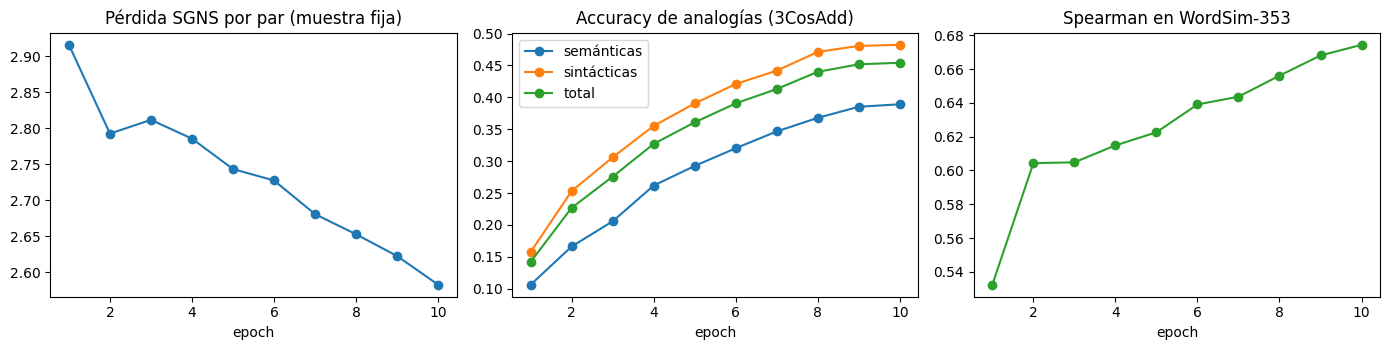

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].plot(history.epoch, history.loss, "o-"); ax[0].set_title("Pérdida SGNS por par (muestra fija)"); ax[0].set_xlabel("epoch")
for col, lab in [("acc_sem", "semánticas"), ("acc_syn", "sintácticas"), ("acc_total", "total")]:
    ax[1].plot(history.epoch, history[col], "o-", label=lab)
ax[1].set_title("Accuracy de analogías (3CosAdd)"); ax[1].set_xlabel("epoch"); ax[1].legend()
ax[2].plot(history.epoch, history.wordsim353, "o-", color="tab:green")
ax[2].set_title("Spearman en WordSim-353"); ax[2].set_xlabel("epoch")
plt.tight_layout(); plt.show()

In [6]:
nb = saved["neighbors"] if cached else {str(e): v for e, v in logger.neighbors_by_epoch.items()}
rows = []
for epoch in [1, GENSIM_CFG["epochs"] // 2, GENSIM_CFG["epochs"]]:
    for w, lst in nb[str(epoch)].items():
        rows.append(dict(epoch=epoch, palabra=w, vecinos=", ".join(f"{n} ({s:.2f})" for n, s in lst)))
pd.DataFrame(rows).set_index(["epoch", "palabra"])

vecinos
epoch palabra                                                    
1     king      aquitaine (0.77), lyon (0.75), moray (0.74), l...
      france    spain (0.80), italy (0.79), belgium (0.79), pa...
      computer  computing (0.77), mainframe (0.77), computers ...
      good      wasted (0.76), clever (0.75), terrific (0.74),...
      january   december (0.86), june (0.84), february (0.84),...
      run       unearned (0.70), partway (0.69), replayed (0.6...
5     king      1329 (0.70), sweyn (0.69), athelstan (0.69), 1...
      france    italy (0.80), spain (0.80), belgium (0.79), po...
      computer  computers (0.79), programmable (0.78), mainfra...
      good      darn (0.70), bad (0.70), enviable (0.69), tris...
      january   february (0.90), december (0.89), march (0.88)...
      run       running (0.68), unearned (0.67), 2-run (0.67),...
10    king      uncrowned (0.79), ealdred (0.77), boleslaus (0...
      france    spain (0.85), italy (0.83), belgium (0.80), po...
      computer  computers (0.81), desktop (0.78), programmable...
      good      bad (0.78), excellent (0.74), enviable (0.70),...
      january   february (0.98), december (0.98), november (0....
      run       running (0.73), 2-run (0.69), ran (0.67), nint...

## 4.B.3 GloVe preentrenado

In [7]:
glove_kv = api.load("glove-wiki-gigaword-100")
glove_space = EV.EmbeddingSpace.from_keyed_vectors(glove_kv, name="GloVe-100")
print(f"GloVe: {len(glove_space):,} palabras x {glove_space.dim} dimensiones")

# Intersección de vocabularios con el corpus propio: cuántas palabras pueden compararse directamente
common = set(glove_space.itos) & set(gensim_space.itos)
print(f"Palabras en común con el vocabulario de gensim/SGNS: {len(common):,} "
      f"({100*len(common)/len(gensim_space):.1f}% del vocabulario propio, {100*len(common)/len(glove_space):.1f}% del de GloVe)")

GloVe: 400,000 palabras x 100 dimensiones
Palabras en común con el vocabulario de gensim/SGNS: 99,473 (90.7% del vocabulario propio, 24.9% del de GloVe)


## 4.B.4 Evaluación de ambos conjuntos

In [8]:
wordsim = EV.load_word_pairs("wordsim353.tsv")
questions = EV.load_analogies()

rows = []
for space in [gensim_space, glove_space]:
    an = EV.evaluate_analogies(space, questions, restrict_vocab=30000)
    ws = EV.word_similarity(space, wordsim)
    rows.append({"modelo": space.name, "vocab": len(space), "dim": space.dim,
                 "cobertura analogías": an["coverage"],
                 "sem (3CosAdd)": an["add"]["semantic"], "sin (3CosAdd)": an["add"]["syntactic"], "total (3CosAdd)": an["add"]["total"],
                 "total (3CosMul)": an["mul"]["total"],
                 "WordSim-353 (Spearman)": ws["spearman"], "pares WS usados": ws["n_used"]})
pd.DataFrame(rows).set_index("modelo").T

modelo,gensim,GloVe-100
vocab,109644.0000,400000.0000
dim,100.0000,100.0000
cobertura analogías,0.6055,0.7612
sem (3CosAdd),0.3891,0.6554
sin (3CosAdd),0.4823,0.6545
total (3CosAdd),0.4542,0.6549
total (3CosMul),0.4262,0.6347
WordSim-353 (Spearman),0.6744,0.5327
pares WS usados,353.0000,353.0000


In [9]:
nb_g = EV.neighbors(gensim_space, EV.CONTROL_WORDS, k=5)
nb_l = EV.neighbors(glove_space, EV.CONTROL_WORDS, k=5)
fmt = lambda lst: ", ".join(n for n, _ in lst) if lst else "(fuera de vocabulario)"
pd.DataFrame({"gensim": {w: fmt(nb_g[w]) for w in EV.CONTROL_WORDS},
              "GloVe-100": {w: fmt(nb_l[w]) for w in EV.CONTROL_WORDS}})

,gensim,GloVe-100
king,"uncrowned, ealdred, boleslaus, harefoot, 1329","prince, queen, son, brother, monarch"
france,"spain, italy, belgium, portugal, netherlands","belgium, french, britain, spain, paris"
computer,"computers, desktop, programmable, software, pdp-1","computers, software, technology, pc, hardware"
good,"bad, excellent, enviable, luck, perfect","better, sure, really, kind, very"
january,"february, december, november, june, march","december, october, february, november, september"
run,"running, 2-run, ran, ninth-inning, inside-the-...","running, runs, ran, out, go"
